In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k8'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    # summary = summary[summary.cluster_size > 4]
    c0 = 857708
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/rheum/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
as_seqs = [
    'CASSVGLFSTDTQYF',
    'CASSVGLYSTDTQYF',
    'CASSAGLFSTDTQYF',
    'CASSAGLYSTDTQYF',
    'CASSLGLFSTDTQYF',
    'CASSLGLYSTDTQYF',
    'CASSPGLFSTDTQYF',
    'CASSPGLYSTDTQYF'
]
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [6]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [7]:
vdjdb

A dataset of 8 clonotypes and 1 clusters

In [8]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [9]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/rheum/tcrempnet_b27pos_k8'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [10]:
def has_vdjdb_match(x, threshold=1):
    return len(vdjdb.get_matching_clonotypes(x, threshold=threshold))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [11]:
metadata = pd.read_csv("/projects/immunestatus/rheum/airr_format/metadata.tsv", sep='\t')

In [12]:
metadata

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
...,...,...,...,...,...,...,...,...
63,Vol,as,pos,NaN,PBMC,NaN,as_Vol_PB_F,bulk
64,ZN,hd,pos,NaN,PBMC,NaN,hd_ZN_PB_F,bulk
65,Zakh,as,pos,NaN,PBMC,NaN,as_Zakh_PB_F,bulk
66,Zbot,hd,pos,NaN,PBMC,NaN,hd_Zbot_PB_F,bulk


In [13]:
metadata_h = metadata[metadata.disease_status != 'as']
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [14]:
metadata = metadata[(metadata.disease_status == 'as') & (~metadata.sample_name.str.contains('CD8'))]

In [15]:
metadata =metadata[metadata.donor_id != 'Mikh']

In [16]:
samples = metadata.sample_name
samples

26           as_Abd_PB_F
27           as_Abr_PB_F
28    as_Ash-110_PB_F_p0
29    as_Ash-111_PB_F_p0
30           as_Bal_PB_F
31           as_Bel_PB_F
32          as_Bost_PB_F
33         as_Chaad_PB_F
36            as_Dv_PB_F
37          as_Evst_PB_F
38            as_GE_PB_F
39           as_Gar_PB_F
40         as_Gonch_PB_F
43           as_Kal_PB_F
44           as_Kud_PB_F
47           as_Luk_PB_F
48          as_Mart_PB_F
56          as_Shep_PB_F
57          as_Tsib_PB_F
58         as_TwHM1_PB_F
60            as_Uv_PB_F
61           as_Vas_PB_F
62          as_Vats_PB_F
63           as_Vol_PB_F
65          as_Zakh_PB_F
67           as_i70_PB_F
Name: sample_name, dtype: object

In [17]:
sample_to_data = {}

for sample in samples:
    info = get_sample_info(sample)
    df = get_clonotypes(sample)
    info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
    sample_to_data[sample] = info


    sample: as_Abd_PB_F
    clusters: 23071
    overall from background: 857708
    overall from sample: 102283
    

    sample: as_Abr_PB_F
    clusters: 21895
    overall from background: 857708
    overall from sample: 65178
    

    sample: as_Ash-110_PB_F_p0
    clusters: 26309
    overall from background: 857708
    overall from sample: 220160
    

    sample: as_Ash-111_PB_F_p0
    clusters: 26025
    overall from background: 857708
    overall from sample: 211288
    

    sample: as_Bal_PB_F
    clusters: 25908
    overall from background: 857708
    overall from sample: 202780
    

    sample: as_Bel_PB_F
    clusters: 22022
    overall from background: 857708
    overall from sample: 75228
    

    sample: as_Bost_PB_F
    clusters: 28779
    overall from background: 857708
    overall from sample: 302672
    

    sample: as_Chaad_PB_F
    clusters: 20982
    overall from background: 857708
    overall from sample: 34613
    

    sample: as_Dv_PB_F
    clusters: 3422

In [18]:
df = sample_to_data['as_i70_PB_F'][0]

In [19]:
import seaborn as sns

In [20]:
df.cluster_size.sum()

128385

In [21]:
df.sort_values(by='cluster_size')

,cluster_id,cluster_size,sample,background,enrichment_pvalue,vdjdb
13342,13342,3,0,3,1.000000,False
13318,13318,3,0,3,1.000000,False
13319,13319,3,0,3,1.000000,False
13320,13320,3,0,3,1.000000,False
13321,13321,3,0,3,1.000000,False
...,...,...,...,...,...,...
76,76,238,10,228,0.626757,False
3271,3271,239,6,233,0.958857,False
202,202,258,23,235,0.001495,False
291,291,371,25,346,0.029640,False


<Axes: xlabel='cluster_size', ylabel='Count'>

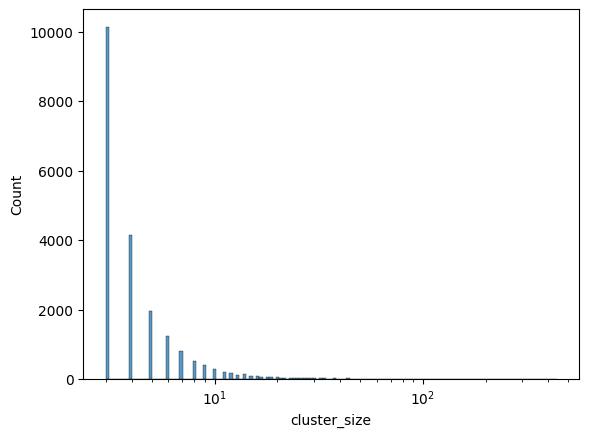

In [22]:
sns.histplot(df[['cluster_id', 'cluster_size']].drop_duplicates().cluster_size, log_scale=True)


In [23]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency, binom
import matplotlib.pyplot as plt
import seaborn as sns

def compute_enrichment_pvalues(df, sample_overall, background_overall, method='fisher'):
    """
    df: DataFrame с колонками ['cluster_id', 'cluster_size', 'sample', 'background']
    sample_overall: общее число клонотипов в sample
    background_overall: общее число клонотипов в background
    method: 'fisher' | 'chi2' | 'binomial'
    """
    results = []

    for _, row in df.iterrows():
        cluster_id = row['cluster_id']
        a = row['sample']  # В кластере, из sample
        b = row['background']  # В кластере, из background
        c = sample_overall - a  # Вне кластера, из sample
        d = background_overall - b  # Вне кластера, из background

        if 'fisher' in method:
            _, pval = fisher_exact([[a, b], [c, d]])
        # elif method == 'chi2':
        #     _, pval, _, _ = chi2_contingency([[a, b], [c, d]])
        elif method == 'binomial':
            p = b / background_overall
            pval = min(binom.sf(k=a, n=sample_overall, p=p), binom.cdf(k=a, n=sample_overall, p=p))
        else:
            raise ValueError("method must be one of 'fisher', 'chi2', 'binomial'")

        fold_enrichment = (a / sample_overall) / ((b + 1e-9) / background_overall)
        results.append({'cluster_id': cluster_id, 'pvalue': pval, 'fold_enrichment': fold_enrichment})

    return pd.DataFrame(results)


In [24]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=2, ax=None):
    df = df.copy()

    if 'vdjdb' not in df.columns:
        raise ValueError("DataFrame должен содержать колонку 'vdjdb'")

    # Преобразования
    df['log10_pval'] = -np.log10(df['pvalue'] + 1e-10)
    df['log2_fc'] = np.log2(df['fold_enrichment'] + 1e-5)
    df['significant'] = (df['pvalue'] < pval_threshold) & (df['fold_enrichment'] > fold_threshold)
    

    # Цветовая кодировка
    def assign_color(row):
        if row['significant'] and row['vdjdb']:
            return 'sign_vdjdb' #'#084594'  # тёмно-синий
        elif row['significant']:
            return 'sign'#'#4292c6'  # голубой
        elif row['vdjdb']:
            return 'vdjdb'#'#fdbb84'  # оранжевый
        else:
            return 'no'#'#ffffb2'  # бледно-жёлтый
    
    colors = {
        'sign_vdjdb': '#084594',  # тёмно-синий
        'sign': '#4292c6',  # голубой
        'vdjdb': '#fdbb84',  # оранжевый
        'no': '#ffffb2'  # бледно-жёлтый
    }
    
    df['label'] = df.apply(assign_color, axis=1)

    # Порог Бонферрони
    bonferroni_thresh = pval_threshold / len(df)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    num_significant = df['significant'].sum()
    num_significant_bonf = (df['pvalue'] < bonferroni_thresh).sum()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Отрисовка
    sns.scatterplot(
        data=df,
        x='log2_fc',
        y='log10_pval',
        hue='label',
        style='vdjdb',
        palette=colors,
        markers={True: 's', False: '.'},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        s=70,
        alpha=0.85,
    )

    # Линии порогов
    ax.axvline(np.log2(fold_threshold), ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'Significant clusters: {num_significant}, after Bonferroni: {num_significant_bonf}')
    ax.legend()

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


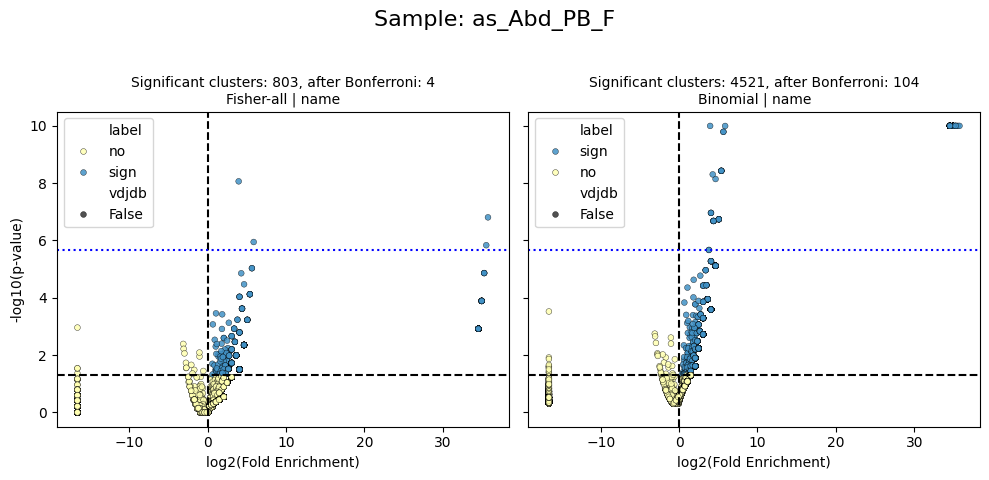

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


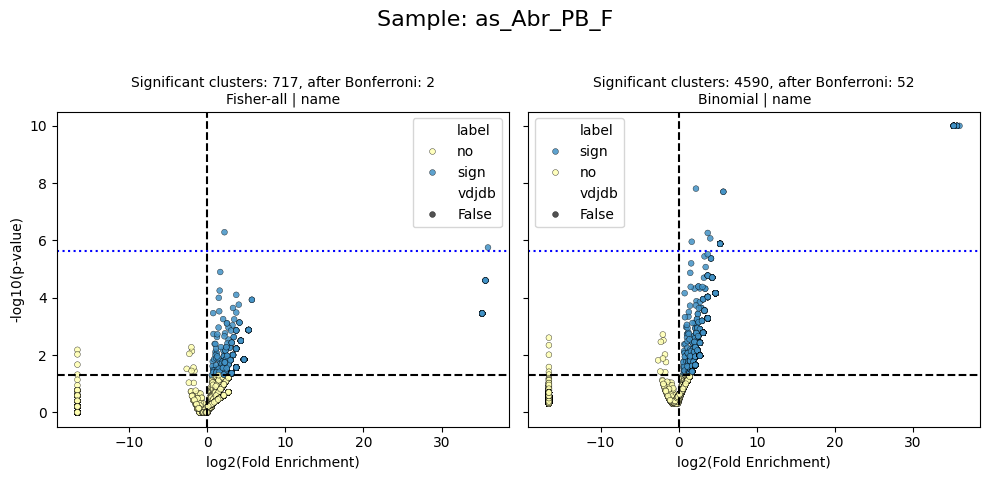

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


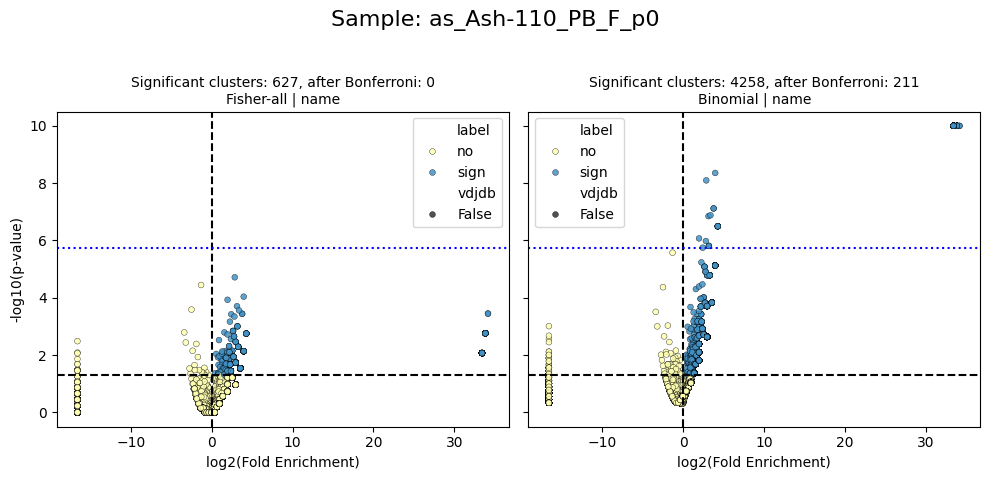

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


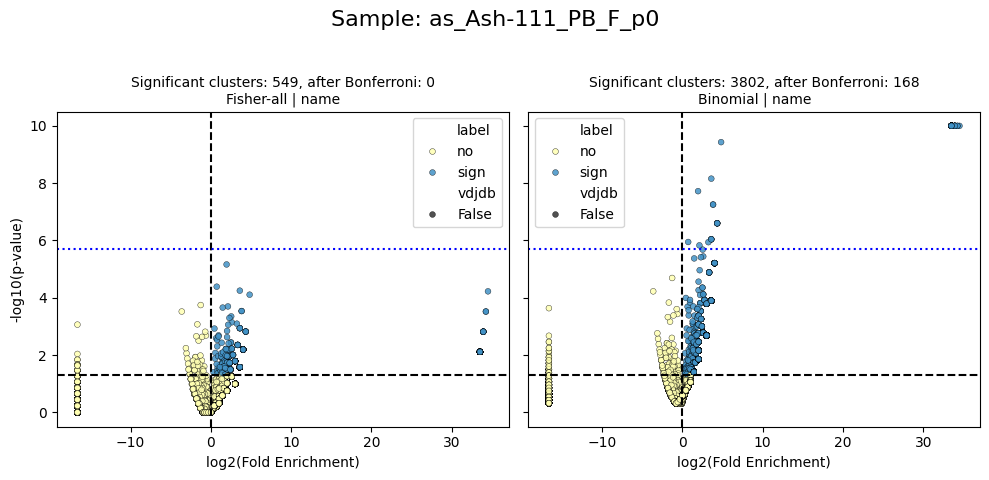

     cluster_id    pvalue  fold_enrichment  vdjdb
488         488  0.028551         5.639662   True
668         668  0.009030         4.229747   True
     cluster_id    pvalue  fold_enrichment  vdjdb
488         488  0.000833         5.639662   True
668         668  0.000325         4.229747   True


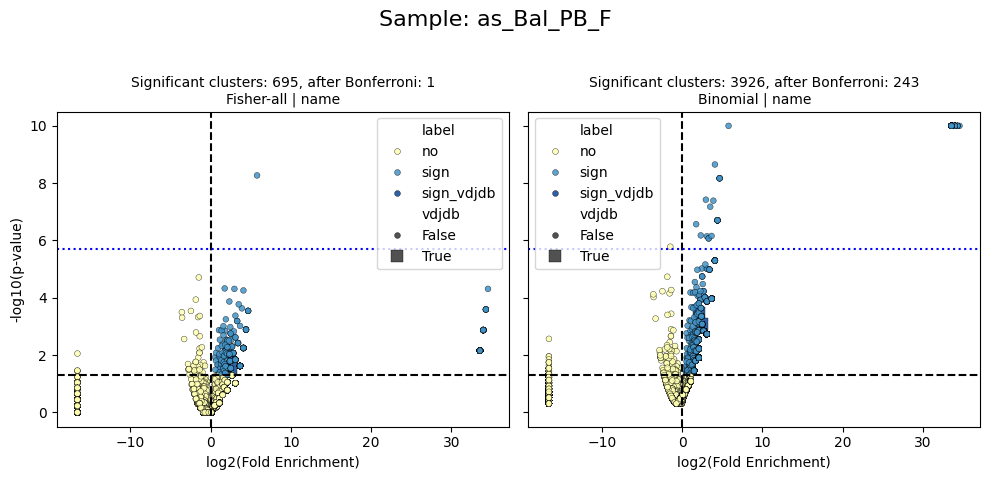

     cluster_id    pvalue  fold_enrichment  vdjdb
960         960  0.018458        22.802893   True
     cluster_id    pvalue  fold_enrichment  vdjdb
960         960  0.000105        22.802893   True


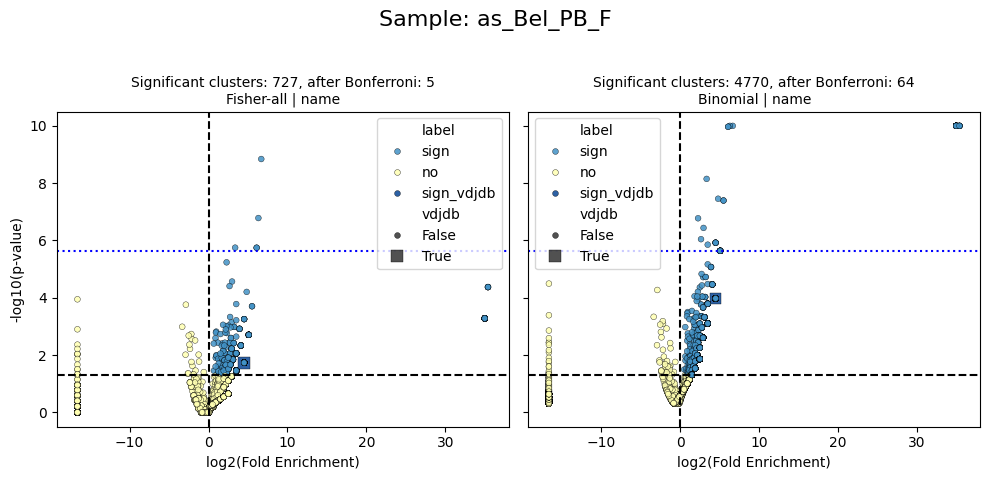

     cluster_id    pvalue  fold_enrichment  vdjdb
427         427  0.001764         9.918255   True
     cluster_id        pvalue  fold_enrichment  vdjdb
427         427  8.173318e-07         9.918255   True


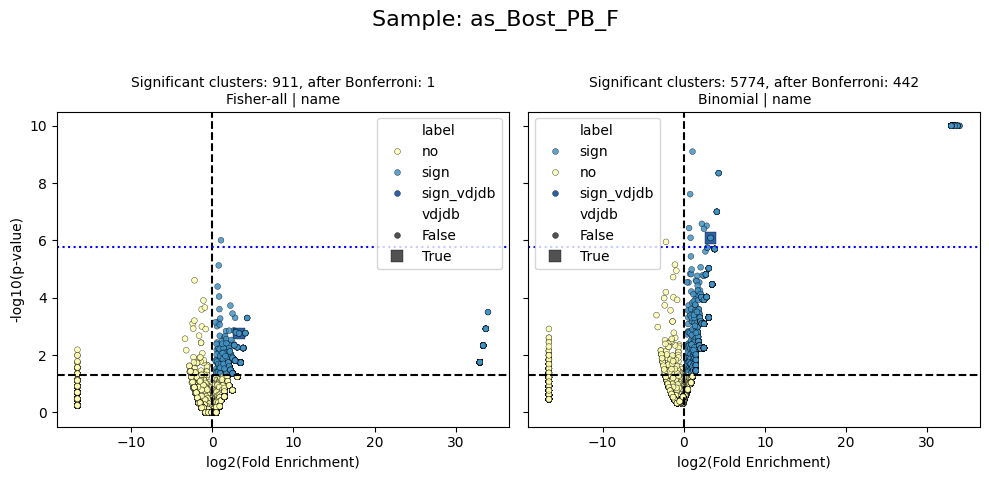

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


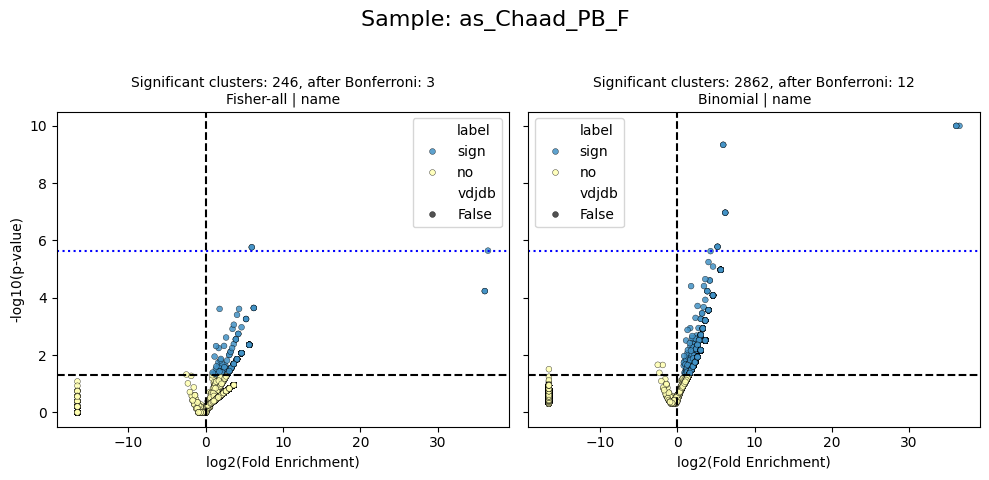

      cluster_id    pvalue  fold_enrichment  vdjdb
5307        5307  0.016305     7.193772e+09   True
      cluster_id  pvalue  fold_enrichment  vdjdb
5307        5307     0.0     7.193772e+09   True


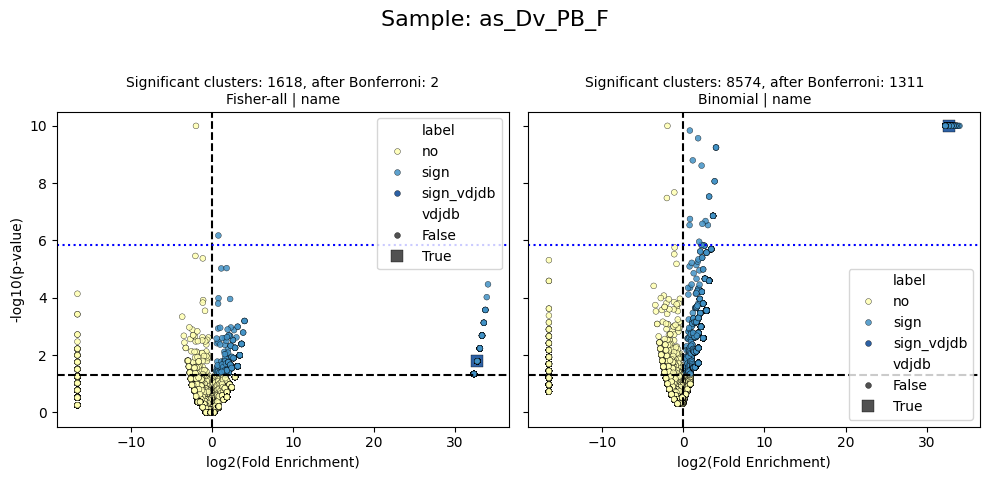

    cluster_id    pvalue  fold_enrichment  vdjdb
48          48  0.001945        12.596681   True
    cluster_id    pvalue  fold_enrichment  vdjdb
48          48  0.000004        12.596681   True


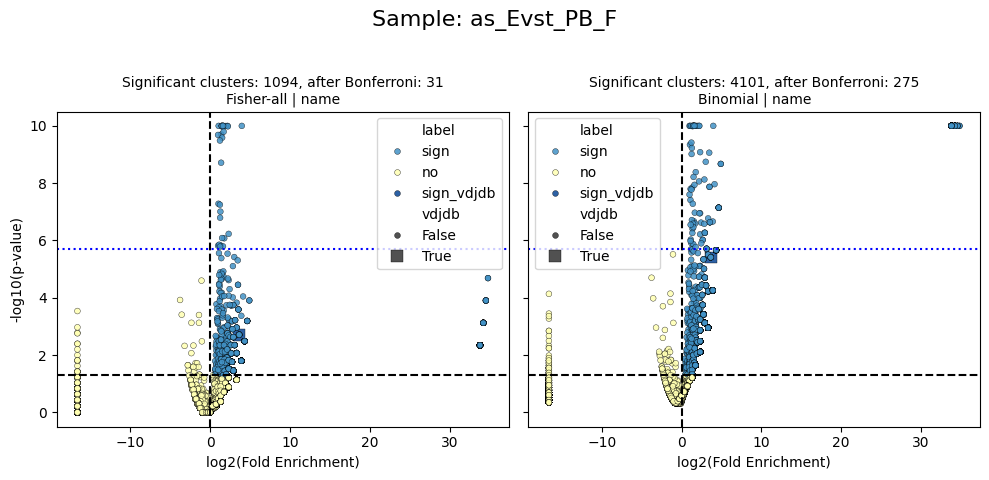

     cluster_id    pvalue  fold_enrichment  vdjdb
44           44  0.002446     1.398621e+10   True
339         339  0.002446     1.398621e+10   True
     cluster_id  pvalue  fold_enrichment  vdjdb
44           44     0.0     1.398621e+10   True
339         339     0.0     1.398621e+10   True


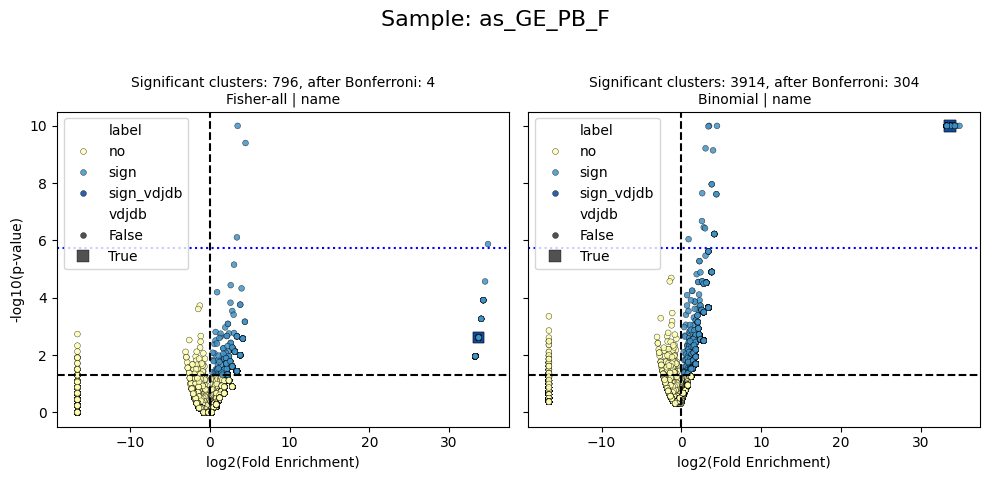

      cluster_id    pvalue  fold_enrichment  vdjdb
2322        2322  0.023353           2.8971   True
      cluster_id    pvalue  fold_enrichment  vdjdb
2322        2322  0.003474           2.8971   True


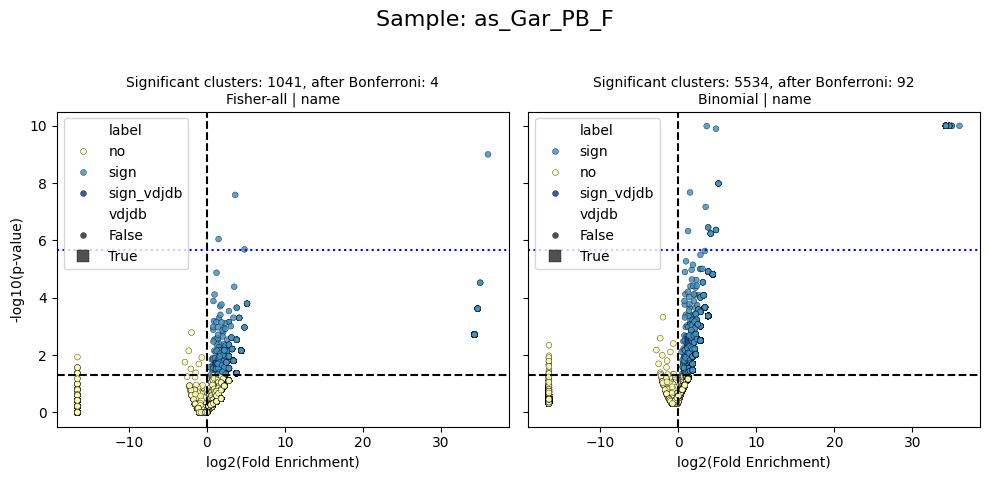

     cluster_id    pvalue  fold_enrichment  vdjdb
593         593  0.006575        21.621074   True
     cluster_id    pvalue  fold_enrichment  vdjdb
593         593  0.000014        21.621074   True


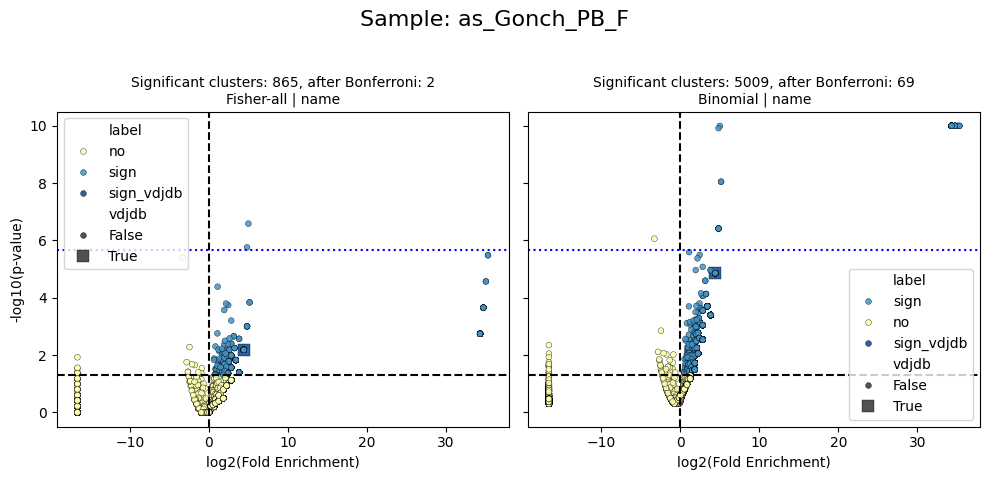

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


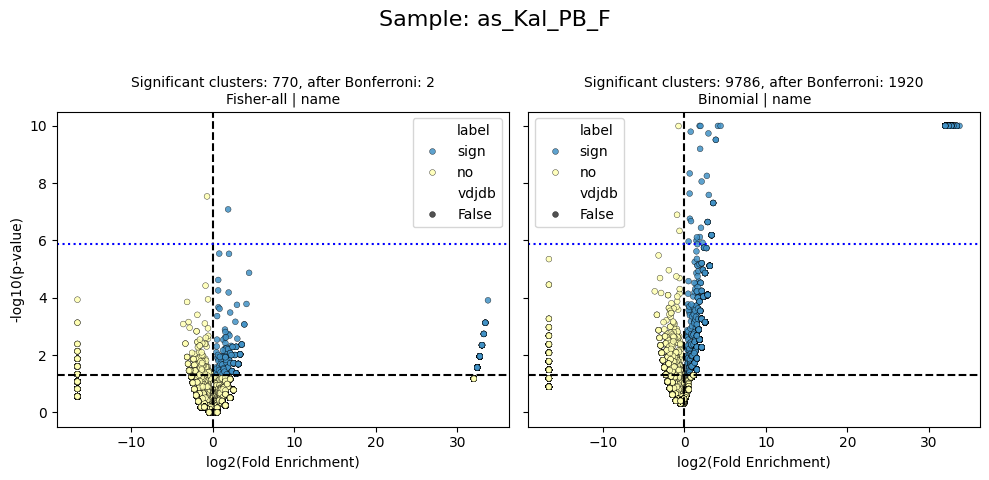

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


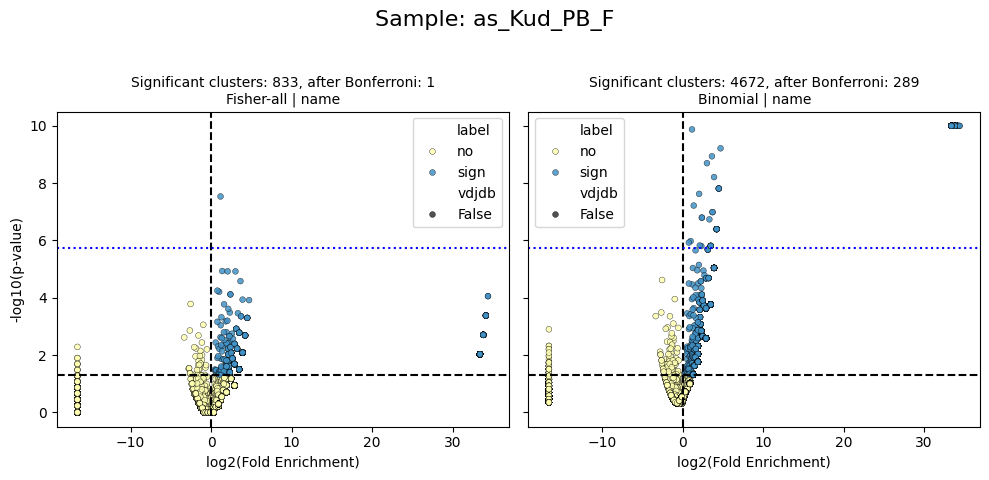

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


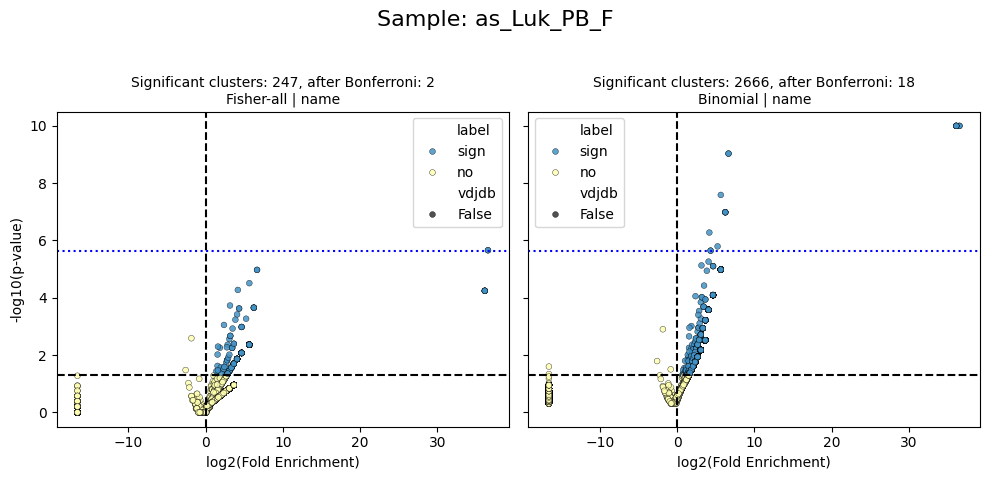

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


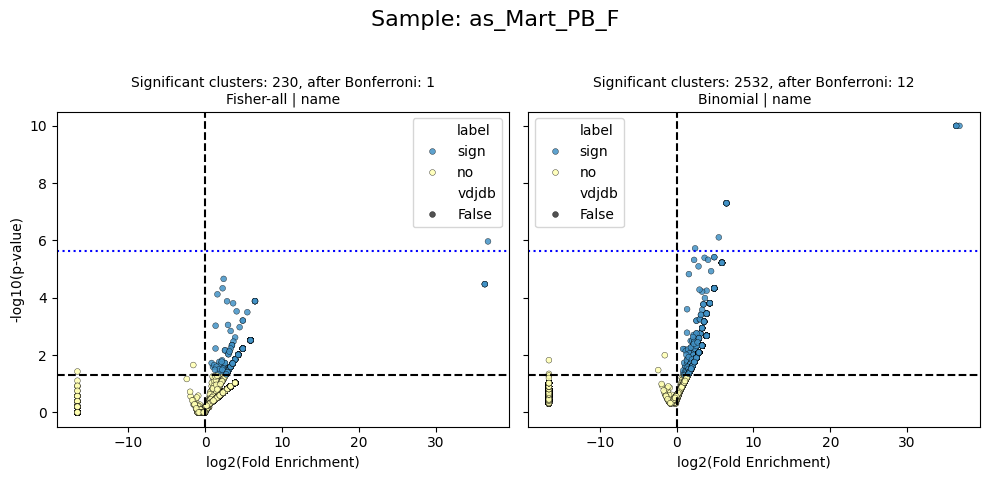

     cluster_id    pvalue  fold_enrichment  vdjdb
247         247  0.000007     2.473730e+10   True
     cluster_id  pvalue  fold_enrichment  vdjdb
247         247     0.0     2.473730e+10   True


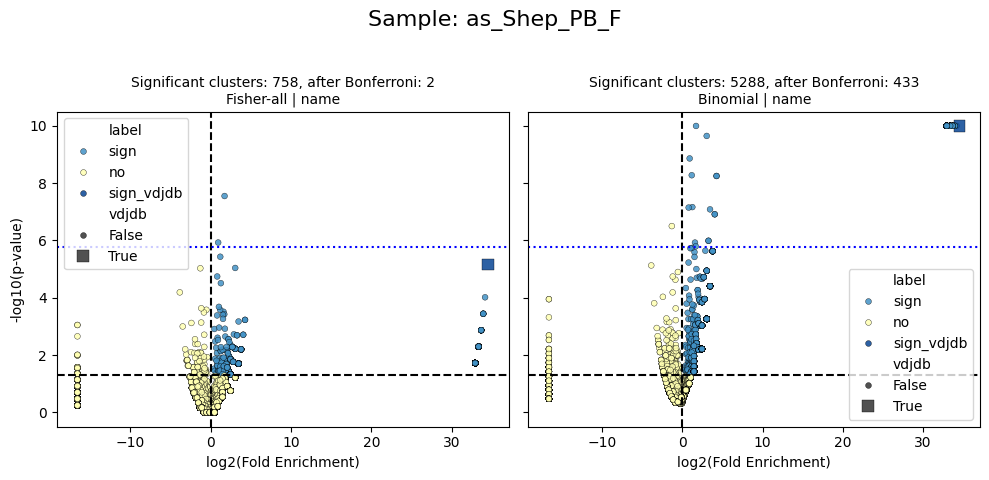

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


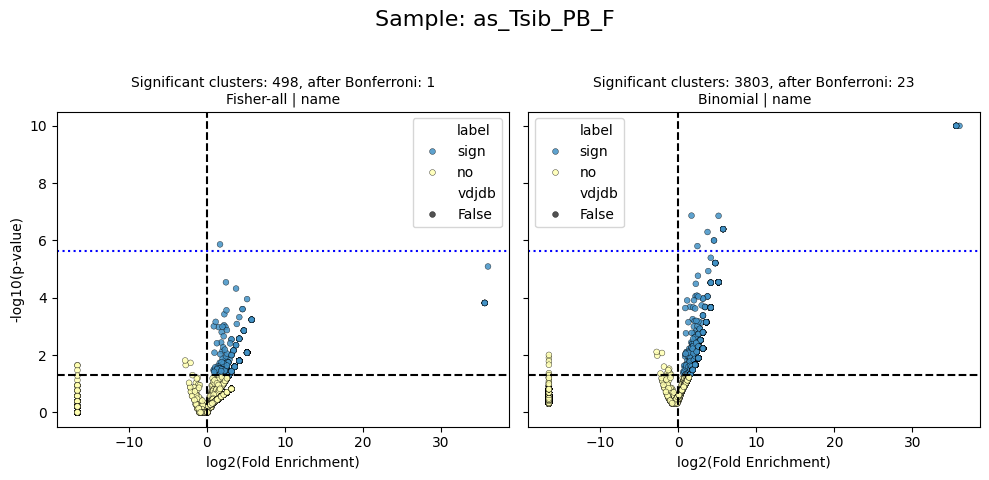

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


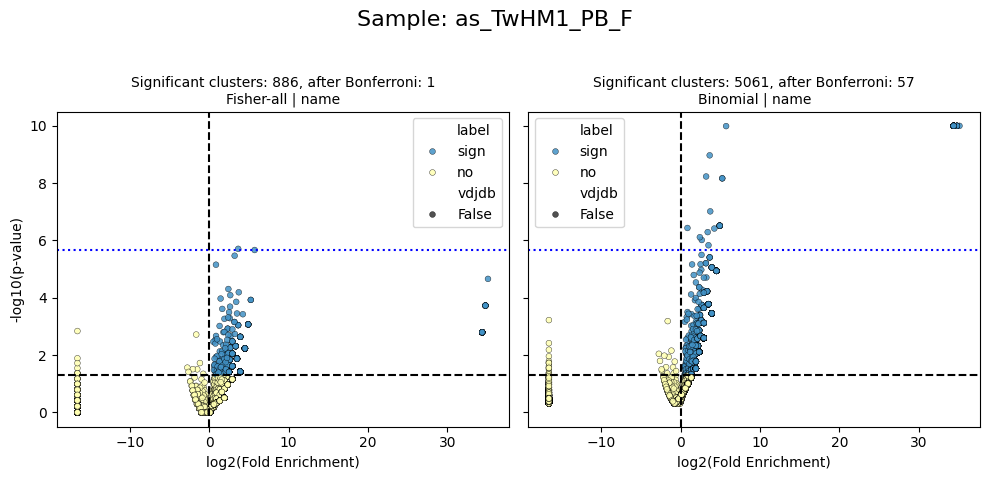

      cluster_id    pvalue  fold_enrichment  vdjdb
4500        4500  0.048208         2.920023   True
      cluster_id    pvalue  fold_enrichment  vdjdb
4500        4500  0.005229         2.920023   True


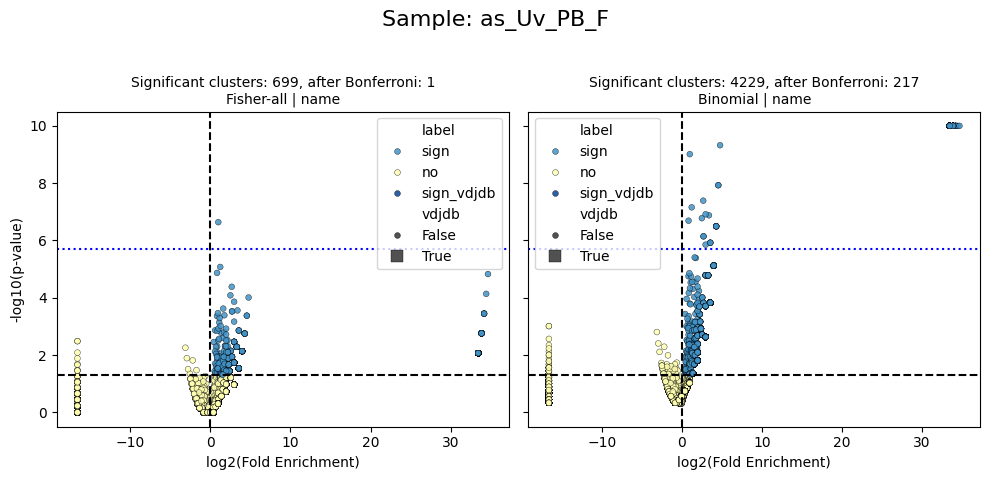

     cluster_id        pvalue  fold_enrichment  vdjdb
139         139  4.017503e-07     5.740585e+01   True
218         218  4.122158e-02     1.435146e+01   True
278         278  1.829829e-03     2.152719e+10   True
     cluster_id        pvalue  fold_enrichment  vdjdb
139         139  4.818135e-14     5.740585e+01   True
218         218  4.064506e-04     1.435146e+01   True
278         278  0.000000e+00     2.152719e+10   True


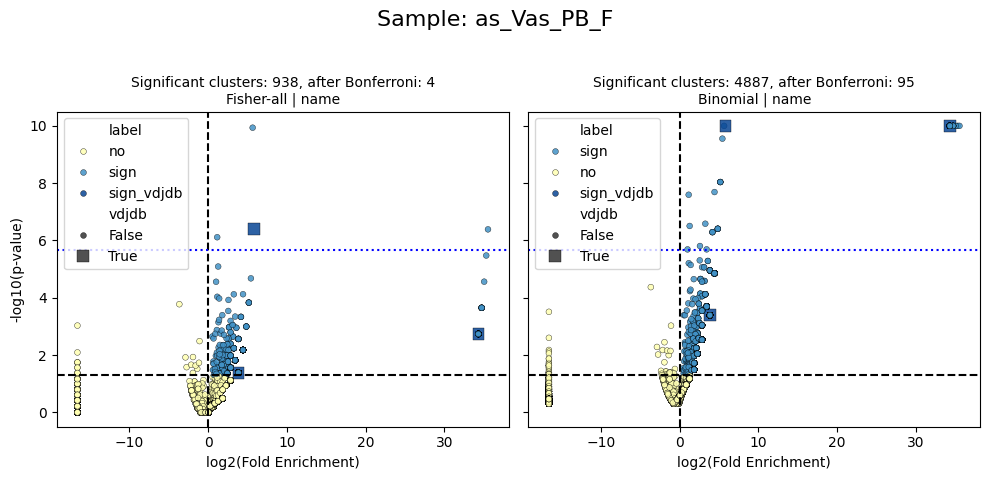

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


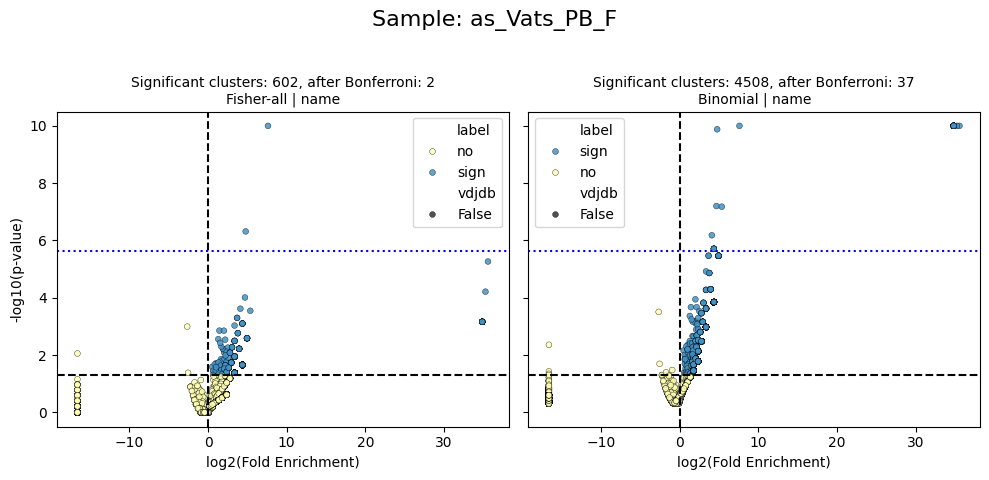

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


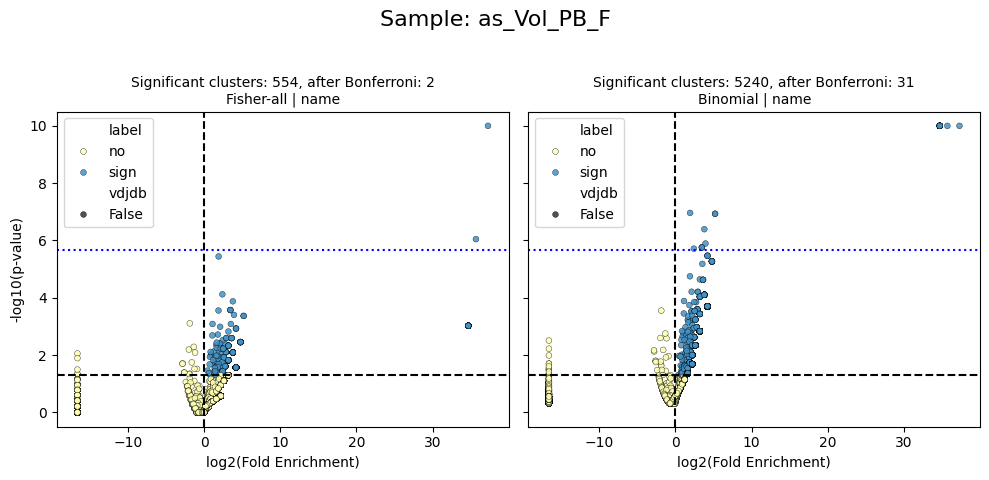

     cluster_id    pvalue  fold_enrichment  vdjdb
106         106  0.000687        17.861939   True
409         409  0.026660         4.121986   True
     cluster_id    pvalue  fold_enrichment  vdjdb
106         106  0.000004        17.861939   True
409         409  0.003226         4.121986   True


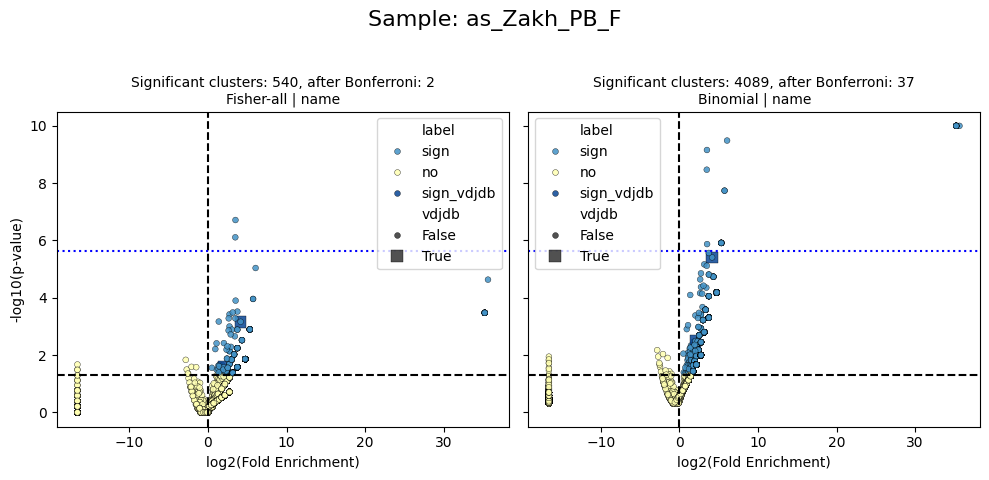

Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []
Empty DataFrame
Columns: [cluster_id, pvalue, fold_enrichment, vdjdb]
Index: []


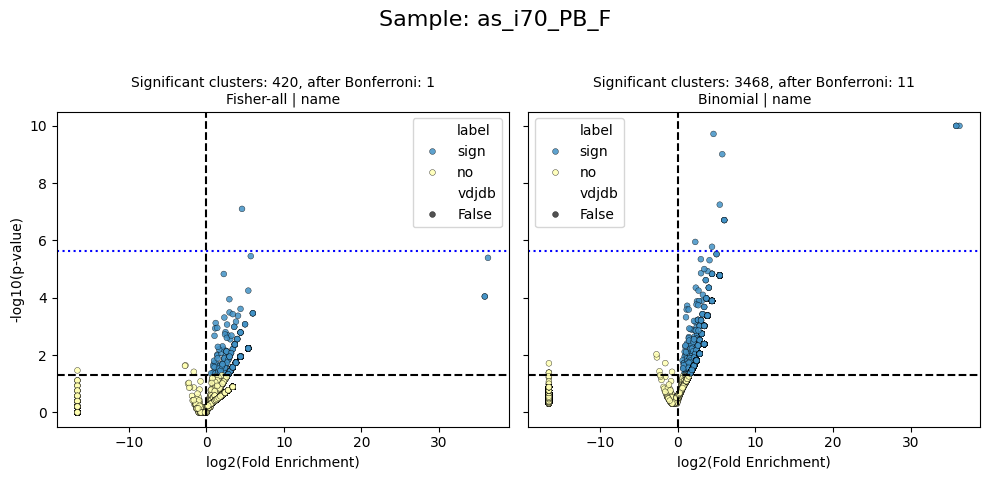

In [26]:
import matplotlib.pyplot as plt

methods = ['fisher-all', 'binomial']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

for s in samples:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            ax = axes[j]
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            print(res_df[res_df.vdjdb])
            plot_volcano(res_df, ax=ax, fold_threshold=1)

            # Не перезаписываем, а дописываем
            old_title = ax.get_title()
            ax.set_title(f"{old_title}\n{method.capitalize()} | {sampling_title}", fontsize=10)
            
    plt.suptitle(f'Sample: {s}', fontsize=16)
    plt.savefig(f'cluster_volcanos/{s}.png', dpi=300)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [27]:
from tqdm import tqdm
methods = ['binomial']
sampling_sets = ['sample_to_data']
sampling_titles = ['name']
sampling_dicts = [sample_to_data]

all_info = []
for s in tqdm(samples):
    for i, (sampling_title, data_dict) in enumerate(zip(sampling_titles, sampling_dicts)):
        s_res = data_dict[s]
        for j, method in enumerate(methods):
            res_df = compute_enrichment_pvalues(
                s_res[0],
                sample_overall=s_res[2],
                background_overall=s_res[1],
                method=method.replace("-all", "")  # remove -all for compatibility
            )
            res_df = res_df.merge(s_res[0][['cluster_id', 'vdjdb']])
            res_df = res_df[(res_df.pvalue < 0.1) & (res_df.fold_enrichment > 0)]
            res_df['sample'] = s
            all_info.append(res_df)

100%|██████████| 26/26 [02:16<00:00,  5.27s/it]


In [28]:
joint = pd.concat(all_info)

In [29]:
joint

,cluster_id,pvalue,fold_enrichment,vdjdb,sample
0,0,0.005850,5.590424,False,as_Abd_PB_F
1,1,0.024299,4.192818,False,as_Abd_PB_F
2,2,0.011247,2.236170,False,as_Abd_PB_F
3,3,0.000514,8.385636,False,as_Abd_PB_F
4,4,0.088682,1.796922,False,as_Abd_PB_F
...,...,...,...,...,...
21124,21124,0.004138,10.655022,False,as_i70_PB_F
21131,21131,0.004138,10.655022,False,as_i70_PB_F
21142,21142,0.004138,10.655022,False,as_i70_PB_F
21145,21145,0.004138,10.655022,False,as_i70_PB_F


In [30]:
joint[joint.vdjdb].sort_values(by='sample')

,cluster_id,pvalue,fold_enrichment,vdjdb,sample
488,488,8.325342e-04,5.639662e+00,True,as_Bal_PB_F
668,668,3.252376e-04,4.229747e+00,True,as_Bal_PB_F
960,960,1.053046e-04,2.280289e+01,True,as_Bel_PB_F
427,427,8.173318e-07,9.918255e+00,True,as_Bost_PB_F
5307,5307,0.000000e+00,7.193772e+09,True,as_Dv_PB_F
48,48,3.869851e-06,1.259668e+01,True,as_Evst_PB_F
44,44,0.000000e+00,1.398621e+10,True,as_GE_PB_F
339,339,0.000000e+00,1.398621e+10,True,as_GE_PB_F
2322,2322,3.474138e-03,2.897100e+00,True,as_Gar_PB_F
593,593,1.382448e-05,2.162107e+01,True,as_Gonch_PB_F


In [31]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient)
    t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [32]:
data = pd.concat(all_clonotypes_enriched).drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name
0,s_10,as_Abd_PB_F_c2,CSVEGGQAYEQYF,TRBV29-1*01,TRBJ2-7*01,0.043998,as_Abd_PB_F
1,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,0.018869,as_Abd_PB_F
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,0.001209,as_Abd_PB_F
3,s_30,as_Abd_PB_F_c9,CSAREREYEQYF,TRBV20-1*01,TRBJ2-7*01,0.011589,as_Abd_PB_F
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.001194,as_Abd_PB_F
...,...,...,...,...,...,...,...
1293,s_40226,as_i70_PB_F_c82,CSVGDTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F
1294,s_40237,as_i70_PB_F_c3729,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F
1295,s_40238,as_i70_PB_F_c3729,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F
1296,s_40240,as_i70_PB_F_c82,CSADTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F


In [33]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [34]:
data[data.vdjdb][['sample_name']].drop_duplicates()

,sample_name
124,as_Bal_PB_F
139,as_Bel_PB_F
113,as_Bost_PB_F
1001,as_Dv_PB_F
29,as_Evst_PB_F
17,as_GE_PB_F
164,as_Gonch_PB_F
69,as_Shep_PB_F
1092,as_Uv_PB_F
60,as_Vas_PB_F


In [ ]:
data.to_csv('as_found_clonotypes_b27pos.csv', index=False)

In [35]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [36]:
import networkx as nx
from collections import defaultdict

In [37]:
df = data

In [38]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [39]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id
0,s_10,as_Abd_PB_F_c2,CSVEGGQAYEQYF,TRBV29-1*01,TRBJ2-7*01,0.043998,as_Abd_PB_F,False,0
1,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,0.018869,as_Abd_PB_F,False,1
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,0.001209,as_Abd_PB_F,False,2
3,s_30,as_Abd_PB_F_c9,CSAREREYEQYF,TRBV20-1*01,TRBJ2-7*01,0.011589,as_Abd_PB_F,False,3
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.001194,as_Abd_PB_F,False,4
...,...,...,...,...,...,...,...,...,...
1293,s_40226,as_i70_PB_F_c82,CSVGDTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134
1294,s_40237,as_i70_PB_F_c3729,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844
1295,s_40238,as_i70_PB_F_c3729,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844
1296,s_40240,as_i70_PB_F_c82,CSADTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134


In [40]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [41]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_10,as_Abd_PB_F_c2,CSVEGGQAYEQYF,TRBV29-1*01,TRBJ2-7*01,0.043998,as_Abd_PB_F,False,0,False
1,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,0.018869,as_Abd_PB_F,False,1,False
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,0.001209,as_Abd_PB_F,False,2,False
3,s_30,as_Abd_PB_F_c9,CSAREREYEQYF,TRBV20-1*01,TRBJ2-7*01,0.011589,as_Abd_PB_F,False,3,False
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.001194,as_Abd_PB_F,False,4,False
...,...,...,...,...,...,...,...,...,...,...
1293,s_40226,as_i70_PB_F_c82,CSVGDTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134,False
1294,s_40237,as_i70_PB_F_c3729,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844,False
1295,s_40238,as_i70_PB_F_c3729,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844,False
1296,s_40240,as_i70_PB_F_c82,CSADTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134,False


In [42]:
df.cluster_id.value_counts()

cluster_id
as_Bost_PB_F_c126    220
as_Kal_PB_F_c325     182
as_Evst_PB_F_c140    177
as_Kal_PB_F_c850     176
as_Shep_PB_F_c79     172
                    ... 
as_i70_PB_F_c3595      2
as_i70_PB_F_c3608      2
as_i70_PB_F_c3623      2
as_i70_PB_F_c3665      2
as_i70_PB_F_c3690      2
Name: count, Length: 19036, dtype: int64

In [43]:
df.merged_cluster_id.value_counts()

merged_cluster_id
134      2928
26       1745
3        1311
131      1259
781      1105
         ... 
12812       2
12813       2
12814       2
12815       2
12818       2
Name: count, Length: 12856, dtype: int64

In [44]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,7,1
1,17,1
2,2,1
3,14,1
4,14,1
...,...,...
12851,1,1
12852,1,1
12853,1,1


In [96]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_10,as_Abd_PB_F_c2,CSVEGGQAYEQYF,TRBV29-1*01,TRBJ2-7*01,0.043998,as_Abd_PB_F,False,0,False
1,s_11,as_Abd_PB_F_c3,CASSLRGAYEQYF,TRBV28*01,TRBJ2-7*01,0.018869,as_Abd_PB_F,False,1,False
2,s_29,as_Abd_PB_F_c8,CASSPPSGSYEQYF,TRBV7-9*01,TRBJ2-7*01,0.001209,as_Abd_PB_F,False,2,False
3,s_30,as_Abd_PB_F_c9,CSAREREYEQYF,TRBV20-1*01,TRBJ2-7*01,0.011589,as_Abd_PB_F,False,3,False
4,s_34,as_Abd_PB_F_c10,CASSLGSYNEQFF,TRBV7-7*01,TRBJ2-1*01,0.001194,as_Abd_PB_F,False,4,False
...,...,...,...,...,...,...,...,...,...,...
1293,s_40226,as_i70_PB_F_c82,CSVGDTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134,False
1294,s_40237,as_i70_PB_F_c3729,CSLGEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844,False
1295,s_40238,as_i70_PB_F_c3729,CSRDEQFF,TRBV20-1*01,TRBJ2-1*01,0.004253,as_i70_PB_F,False,844,False
1296,s_40240,as_i70_PB_F_c82,CSADTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134,False


In [45]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

,sample_name,as_pattern
merged_cluster_id,,
0,7,False
1,17,False
2,2,False
3,14,False
4,14,False
...,...,...
12851,1,False
12852,1,False
12853,1,False


In [46]:
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")
n_patients = df.groupby('merged_cluster_id').agg({
                    'sample_name': 'nunique',     
                    'as_pattern': 'any'          
                }).reset_index().rename(columns={'sample_name': "n_patients"})
summary = pd.merge(cluster_sizes, n_patients, on="merged_cluster_id")
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [47]:
summary

,merged_cluster_id,cluster_size,n_patients,as_pattern
26,26,1745,25,False
114,114,879,25,False
7,7,877,25,False
161,161,574,25,False
577,577,1077,24,False
...,...,...,...,...
12851,12851,2,1,False
12852,12852,2,1,False
12853,12853,2,1,False
12854,12854,2,1,False


In [95]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

,merged_cluster_id,cluster_size,n_patients,as_pattern
134,134,2928,19,False
26,26,1745,25,False
3,3,1311,14,False
131,131,1259,23,False
781,781,1105,15,False
577,577,1077,24,False
323,323,1037,23,False
114,114,879,25,False
7,7,877,25,False
52,52,829,13,False


In [48]:
summary[summary.as_pattern]

,merged_cluster_id,cluster_size,n_patients,as_pattern
2332,2332,65,11,True
6223,6223,7,2,True


In [97]:
df[df.merged_cluster_id == 134]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
179,s_2716,as_Abd_PB_F_c386,CSGLEQETQYF,TRBV29-1*01,TRBJ2-5*01,0.000566,as_Abd_PB_F,False,134,False
314,s_6138,as_Abd_PB_F_c386,CSVVAYQETQYF,TRBV29-1*01,TRBJ2-5*01,0.000566,as_Abd_PB_F,False,134,False
315,s_6139,as_Abd_PB_F_c386,CSVVAVEETQYF,TRBV29-1*01,TRBJ2-5*01,0.000566,as_Abd_PB_F,False,134,False
321,s_6212,as_Abd_PB_F_c386,CSVAFQETQYF,TRBV29-1*01,TRBJ2-5*01,0.000566,as_Abd_PB_F,False,134,False
322,s_6213,as_Abd_PB_F_c386,CSVEERETQYF,TRBV29-1*01,TRBJ2-5*01,0.000566,as_Abd_PB_F,False,134,False
...,...,...,...,...,...,...,...,...,...,...
1287,s_40183,as_i70_PB_F_c291,CSVRTETQYF,TRBV29-1*01,TRBJ2-5*01,0.029640,as_i70_PB_F,False,134,False
1290,s_40196,as_i70_PB_F_c291,CSGRTETQYF,TRBV29-1*01,TRBJ2-5*01,0.029640,as_i70_PB_F,False,134,False
1292,s_40220,as_i70_PB_F_c291,CSVGETQYF,TRBV29-1*01,TRBJ2-5*01,0.029640,as_i70_PB_F,False,134,False
1293,s_40226,as_i70_PB_F_c82,CSVGDTQYF,TRBV29-1*01,TRBJ2-3*01,0.012797,as_i70_PB_F,False,134,False


In [52]:
df[(df.merged_cluster_id == 2332) & ~(df.as_pattern)]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
168,s_5030,as_Bal_PB_F_c668,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
354,s_14064,as_Bal_PB_F_c668,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
613,s_30978,as_Bal_PB_F_c668,CASSLGTPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
639,s_31339,as_Bal_PB_F_c668,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
640,s_31353,as_Bal_PB_F_c668,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
1521,s_117019,as_Bal_PB_F_c668,CASSLGTPATDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
1095,s_104504,as_Uv_PB_F_c4500,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False
1098,s_104556,as_Uv_PB_F_c4500,CASSLGYVSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False
1118,s_104910,as_Uv_PB_F_c4500,CASSLGTVNADTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False
1244,s_107441,as_Uv_PB_F_c4500,CASSLGFTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False


In [51]:
df[df.merged_cluster_id == 6223]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
115,s_2559,as_GE_PB_F_c339,CASSAGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.002445,as_GE_PB_F,True,6223,True
127,s_2800,as_GE_PB_F_c339,CASSSGLFSTDTQYF,TRBV9*01,TRBJ2-3*01,0.002445,as_GE_PB_F,True,6223,True
493,s_15578,as_GE_PB_F_c339,CASSSGLFSTDTQYF,TRBV9*01,TRBJ2-3*01,0.002445,as_GE_PB_F,True,6223,True
1688,s_125672,as_GE_PB_F_c339,CASSSGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.002445,as_GE_PB_F,True,6223,True
127,s_2180,as_Vas_PB_F_c278,CASSSGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.001830,as_Vas_PB_F,True,6223,True
159,s_3084,as_Vas_PB_F_c278,CASSAGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.001830,as_Vas_PB_F,True,6223,True
215,s_4768,as_Vas_PB_F_c278,CASSAGLFSTDTQYF,TRBV9*01,TRBJ2-3*01,0.001830,as_Vas_PB_F,True,6223,True


In [53]:
as_found_seqs = df[(df.merged_cluster_id == 2332) | (df.merged_cluster_id == 6223)].cdr3aa_beta

In [54]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_found_seqs]
dataset = ClonotypeDataset(found_clonotypes)

In [55]:
dataset.clonotype_clustering

,cdr3aa,cluster
vertex ID,,
0,CASSVGLYSTDTQYF,0
1,CASSVGLFSTDTQYF,0
2,CASSLGLYSTDTQYF,0
3,CASSVGVYSTDTQYF,0
4,CASSAGLYSTDTQYF,0
5,CASSSGLYSTDTQYF,0
6,CASSIGLYSTDTQYF,0
7,CASSVGTYSTDTQYF,0
8,CASSLGPTSTDTQYF,1


In [57]:
import logomaker

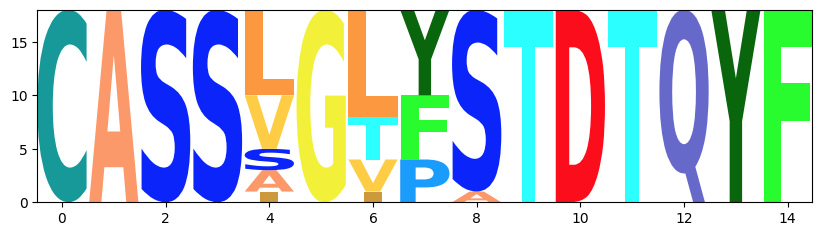

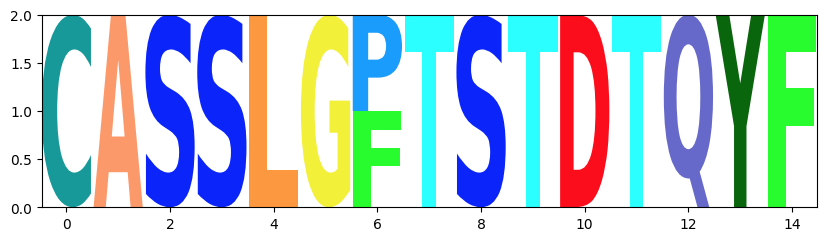

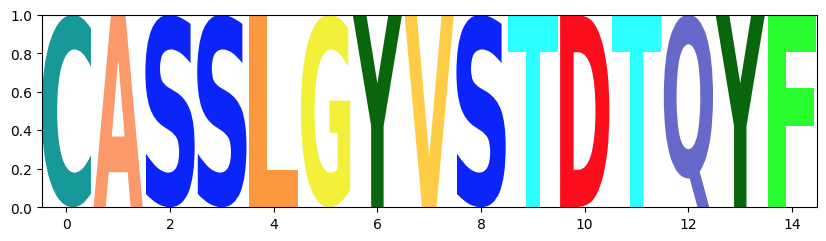

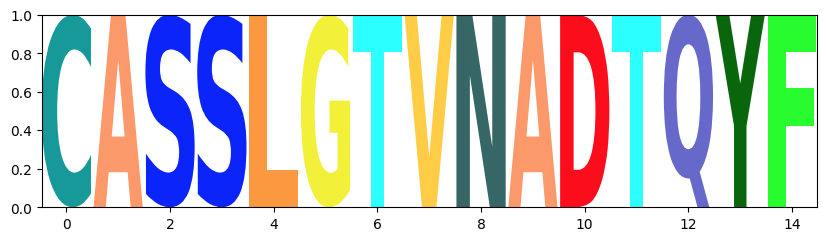

In [59]:
for i in range(4):
    seqs = dataset.clonotype_clustering[dataset.clonotype_clustering.cluster == i].cdr3aa
    mat_df = logomaker.alignment_to_matrix(seqs)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

In [ ]:
samples

In [60]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
metadata = metadata.reset_index(drop=True)

In [62]:
found_clonotypes

[κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGPTSTDTQYF,
 κ-1 CASSVGVFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGIYSTDTQYF,
 κ-1 CASSLGVPSTDTQYF,
 κ-1 CASSLGTPSTDTQYF,
 κ-1 CASSLGPTSTDTQYF,
 κ-1 CASSLGVPSTDTQYF,
 κ-1 CASSLGTPATDTQYF,
 κ-1 CASSLGLPSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSLGLFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGVYSTDTQYF,
 κ-1 CASSLGTFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGVYSTDTQYF,
 κ-1 CASSLGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSAGLYSTDTQYF,
 κ-1 CASSSGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSSGLFSTDTQYF,
 κ-1 CASSSGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSLGLYSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSVGLFSTDTQYF,
 κ-1 CASSV

In [63]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 26/26 [00:40<00:00,  1.57s/it]

41.34566521644592


In [64]:
dataset_found = dataset.subsample_by_lambda(lambda x: x.cdr3aa in set([x.cdr3aa for x in found_clonotypes]))

In [67]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [68]:
public_clonotypes = [ClonotypeRepresentation(cdr3aa=x) for x in set(y.cdr3aa for y in found_clonotypes)]

In [69]:
dataset_found.repertoire_matrix_public_clonotypes = public_clonotypes

In [70]:
dataset_found[20]

Repertoire of 11 clonotypes and 11 cells:
κ1947 CASSLGLFSTDTQYF
κ1966 CASSVGVYSTDTQYF
κ14732 CASSLGPTSTDTQYF
κ79101 CASSLGTPSTDTQYF
κ97569 CASSVGTYSTDTQYF
donor_id                                                         Uv
disease_status                                                   as
b27                                                             pos
proj                                                            NaN
sample_type                                                    PBMC
time_point                                                      NaN
sample_name                                              as_Uv_PB_F
fraction                                                       bulk
path              /projects/immunestatus/rheum/airr_format/as_Uv...
Name: 20, dtype: object
...

In [71]:
metadata_h =metadata_h.reset_index(drop=True)

In [72]:
metadata_h

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN


In [73]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/rheum/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

loading Repertoire objects: 100%|██████████| 33/33 [01:04<00:00,  1.95s/it]


65.59321117401123


In [74]:
dataset_h.repertoire_matrix_public_clonotypes = public_clonotypes


In [75]:
dataset_h_found = dataset_h.subsample_by_lambda(lambda x: x.cdr3aa in set([x.cdr3aa for x in found_clonotypes]))

In [76]:
dataset_h_found.repertoire_matrix_public_clonotypes = public_clonotypes

In [77]:
dataset_h_found.clonotype_usage_matrix.public_clonotypes

clonotype usage matrix should be calculated. it would take a while
there are 22 public clonotypes


[ClonotypeRepresentation(cdr3aa='CASSSGLYSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSLGFTSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSLGLPSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSAGLFSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSAGLYSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSVGVYSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSLGTPSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSVGLFSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSLGTPATDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSVGVFSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSLGPTSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr3aa='CASSIGLYSTDTQYF', v=None, j=None, cdr3nt=None),
 ClonotypeRepresentation(cdr

In [78]:
dataset_h_found[0]

Repertoire of 2 clonotypes and 2 cells:
κ12337 CASSLGTPSTDTQYF
κ47372 CASSLGTPSTDTQYF
donor_id                                                       Koc
disease_status                                                  hd
b27                                                            pos
proj                                                          GCSF
sample_type                                                   PBMC
time_point                                            normal blood
sample_name                                                    Koc
fraction                                                       NaN
path              /projects/immunestatus/rheum/airr_format/Koc.tsv
Name: 0, dtype: object
...

In [79]:
healthy_usage = pd.DataFrame.sparse.from_spmatrix(dataset_h_found.clonotype_usage_matrix.clonotype_database_usage,
                                 columns=[x.cdr3aa for x in dataset_h_found.clonotype_usage_matrix.public_clonotypes])

created MultipleRepertoireDenseMatcher
started with 16 threads


repertoire dataset serialization: 33it [00:00, 2701.09it/s]

all in all 33 reps, chunk size is 3, number of batches 11



clonotype usage matrix preparation: 100%|██████████| 11/11 [00:00<00:00, 730.30it/s]


In [80]:
as_usage = pd.DataFrame.sparse.from_spmatrix(dataset_found.clonotype_usage_matrix.clonotype_database_usage,
                                 columns=[x.cdr3aa for x in dataset_found.clonotype_usage_matrix.public_clonotypes])

clonotype usage matrix should be calculated. it would take a while
there are 22 public clonotypes
created MultipleRepertoireDenseMatcher
started with 16 threads


repertoire dataset serialization: 26it [00:00, 3028.88it/s]

all in all 26 reps, chunk size is 2, number of batches 13



clonotype usage matrix preparation: 100%|██████████| 13/13 [00:00<00:00, 713.55it/s]


In [81]:
healthy_usage.columns

Index(['CASSSGLYSTDTQYF', 'CASSLGFTSTDTQYF', 'CASSLGLPSTDTQYF',
       'CASSAGLFSTDTQYF', 'CASSAGLYSTDTQYF', 'CASSVGVYSTDTQYF',
       'CASSLGTPSTDTQYF', 'CASSVGLFSTDTQYF', 'CASSLGTPATDTQYF',
       'CASSVGVFSTDTQYF', 'CASSLGPTSTDTQYF', 'CASSIGLYSTDTQYF',
       'CASSLGTVNADTQYF', 'CASSVGLYSTDTQYF', 'CASSLGVPSTDTQYF',
       'CASSLGLYSTDTQYF', 'CASSLGLFSTDTQYF', 'CASSSGLFSTDTQYF',
       'CASSLGIYSTDTQYF', 'CASSLGYVSTDTQYF', 'CASSVGTYSTDTQYF',
       'CASSLGTFSTDTQYF'],
      dtype='object')

In [82]:
as_usage.columns

Index(['CASSSGLYSTDTQYF', 'CASSLGFTSTDTQYF', 'CASSLGLPSTDTQYF',
       'CASSAGLFSTDTQYF', 'CASSAGLYSTDTQYF', 'CASSVGVYSTDTQYF',
       'CASSLGTPSTDTQYF', 'CASSVGLFSTDTQYF', 'CASSLGTPATDTQYF',
       'CASSVGVFSTDTQYF', 'CASSLGPTSTDTQYF', 'CASSIGLYSTDTQYF',
       'CASSLGTVNADTQYF', 'CASSVGLYSTDTQYF', 'CASSLGVPSTDTQYF',
       'CASSLGLYSTDTQYF', 'CASSLGLFSTDTQYF', 'CASSSGLFSTDTQYF',
       'CASSLGIYSTDTQYF', 'CASSLGYVSTDTQYF', 'CASSVGTYSTDTQYF',
       'CASSLGTFSTDTQYF'],
      dtype='object')

In [85]:
def found_in_x_patients(usage_df, clonotype):
    # if clonotype in usage_df.columns:
    return (usage_df[clonotype] != 0).sum() 
    # return 0

In [87]:
cluster573 = df[(df.merged_cluster_id == 2332) | (df.merged_cluster_id == 6223)]
cluster573.head()

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern
124,s_3471,as_Bal_PB_F_c488,CASSVGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.028551,as_Bal_PB_F,True,2332,True
168,s_5030,as_Bal_PB_F_c668,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False
190,s_6292,as_Bal_PB_F_c488,CASSVGVFSTDTQYF,TRBV9*01,TRBJ2-3*01,0.028551,as_Bal_PB_F,True,2332,True
191,s_6294,as_Bal_PB_F_c488,CASSVGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.028551,as_Bal_PB_F,True,2332,True
250,s_8570,as_Bal_PB_F_c488,CASSLGIYSTDTQYF,TRBV9*01,TRBJ2-3*01,0.028551,as_Bal_PB_F,True,2332,True


In [88]:
cluster573['hd_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(healthy_usage, x))

/scratch/ipykernel_483614/2376103890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster573['hd_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(healthy_usage, x))


In [89]:
cluster573['as_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(as_usage, x))

/scratch/ipykernel_483614/3582622078.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster573['as_usage'] = cluster573.cdr3aa_beta.apply(lambda x: found_in_x_patients(as_usage, x))


In [92]:
cluster573[~cluster573.as_pattern]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern,hd_usage,as_usage
168,s_5030,as_Bal_PB_F_c668,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,14,13
354,s_14064,as_Bal_PB_F_c668,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,21,16
613,s_30978,as_Bal_PB_F_c668,CASSLGTPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,21,17
639,s_31339,as_Bal_PB_F_c668,CASSLGPTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,14,13
640,s_31353,as_Bal_PB_F_c668,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,21,16
1521,s_117019,as_Bal_PB_F_c668,CASSLGTPATDTQYF,TRBV5-1*01,TRBJ2-3*01,0.009030,as_Bal_PB_F,False,2332,False,9,11
1095,s_104504,as_Uv_PB_F_c4500,CASSLGVPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False,21,16
1098,s_104556,as_Uv_PB_F_c4500,CASSLGYVSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False,0,1
1118,s_104910,as_Uv_PB_F_c4500,CASSLGTVNADTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False,0,1
1244,s_107441,as_Uv_PB_F_c4500,CASSLGFTSTDTQYF,TRBV5-1*01,TRBJ2-3*01,0.048191,as_Uv_PB_F,False,2332,False,14,13


In [93]:
cluster573[cluster573.as_pattern]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,enrichment_pvalue,sample_name,vdjdb,merged_cluster_id,as_pattern,hd_usage,as_usage
124,s_3471,as_Bal_PB_F_c488,CASSVGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,2.855072e-02,as_Bal_PB_F,True,2332,True,2,17
190,s_6292,as_Bal_PB_F_c488,CASSVGVFSTDTQYF,TRBV9*01,TRBJ2-3*01,2.855072e-02,as_Bal_PB_F,True,2332,True,2,13
191,s_6294,as_Bal_PB_F_c488,CASSVGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,2.855072e-02,as_Bal_PB_F,True,2332,True,2,17
250,s_8570,as_Bal_PB_F_c488,CASSLGIYSTDTQYF,TRBV9*01,TRBJ2-3*01,2.855072e-02,as_Bal_PB_F,True,2332,True,0,7
1533,s_117315,as_Bal_PB_F_c668,CASSLGLPSTDTQYF,TRBV5-1*01,TRBJ2-3*01,9.030176e-03,as_Bal_PB_F,True,2332,True,22,19
...,...,...,...,...,...,...,...,...,...,...,...,...
1001,s_59939,as_Vas_PB_F_c139,CASSIGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,4.017038e-07,as_Vas_PB_F,True,2332,True,1,15
30,s_810,as_Zakh_PB_F_c106,CASSVGVFSTDTQYF,TRBV9*01,TRBJ2-3*01,6.864212e-04,as_Zakh_PB_F,True,2332,True,2,13
40,s_1228,as_Zakh_PB_F_c106,CASSVGTYSTDTQYF,TRBV9*01,TRBJ2-3*01,6.864212e-04,as_Zakh_PB_F,True,2332,True,1,14
341,s_29059,as_Zakh_PB_F_c106,CASSVGVYSTDTQYF,TRBV9*01,TRBJ2-3*01,6.864212e-04,as_Zakh_PB_F,True,2332,True,2,14
